In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datasets import load_dataset, Audio
from transformers import (
    WhisperProcessor, WhisperForConditionalGeneration,
    WhisperFeatureExtractor, WhisperTokenizer,
    Seq2SeqTrainer, Seq2SeqTrainingArguments)
from jiwer import wer, cer
from dataclasses import dataclass
from typing import Any, Dict, List, Union
import re
import os
import json
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


This one is crucial for setting up the environment and verifying our hardware before proceeding with the main tasks. Here's a breakdown:

- *numpy*: For numerical operations, especially with arrays.
- *torch*: The PyTorch deep learning framework, essential for model operations.
- *matplotlib.pyplot and matplotlib.ticker*: For creating various plots and customizing their axes.
- *from datasets import load_dataset, Audio*: Imports load_dataset for fetching datasets from the Hugging Face Hub and Audio for handling audio data.
- *transformers*: Imports various components from the Hugging Face transformers library, which is central to this project:
  - *WhisperProcessor*: Handles both feature extraction and tokenization for the Whisper model.
  - *WhisperForConditionalGeneration*: The actual Whisper model architecture.
  - *WhisperFeatureExtractor*: Extracts audio features (like mel spectrograms) from raw audio.
  - *WhisperTokenizer*: Converts text to token IDs and vice-versa.
  - *Seq2SeqTrainer, Seq2SeqTrainingArguments*: Tools for fine-tuning sequence-to-sequence models.
- *from jiwer import wer, cer*: Imports functions to calculate Word Error Rate (WER) and Character Error Rate (CER), common metrics for ASR models.
- *from dataclasses import dataclass, from typing import Any, Dict, List, Union* These are standard Python modules for defining data classes and type hinting, which improve code readability and maintainability.

- *import re, os, json, warnings*: re: For regular expressions (regex). os: For interacting with the operating system (e.g., file paths).json: For working with JSON data. warnings: For controlling warning messages, with warnings.filterwarnings('ignore') suppressing all warnings.
- `print(f'Device: {'cuda' if torch.cuda.is_available() else 'cpu'}')`: This line checks if a CUDA-enabled GPU is available and prints whether the device being used is cuda (GPU) or cpu.

- `print(f'GPU: {torch.cuda.get_device_name(0)}')`: If a GPU is available, this prints the name of the first detected GPU (e.g., 'Tesla T4').

- `print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')`If a GPU is available, this prints the total video RAM (VRAM) of the first GPU in gigabytes, rounded to one decimal place. This is important for understanding memory limitations for model sizes and batch sizes.

# PART B - Fine-Tuning

## B1. Data Preparation

In [ ]:
ds_train_raw = load_dataset("fsicoli/common_voice_22_0", "az", split = 'train', trust_remote_code = True)
ds_val_raw   = load_dataset("fsicoli/common_voice_22_0", "az", split = 'validation', trust_remote_code=True)
print(f'Train: {len(ds_train_raw)}')
print(f'Val: {len(ds_val_raw)}')

ds_train_raw = ds_train_raw.shuffle(seed = 42).select(range(min(200, len(ds_train_raw))))
ds_val_raw = ds_val_raw.shuffle(seed = 42).select(range(min(50, len(ds_val_raw))))
# Cast to 16 kHz
ds_train_raw = ds_train_raw.cast_column('audio', Audio(sampling_rate = 16000))
ds_val_raw = ds_val_raw.cast_column('audio', Audio(sampling_rate = 16000))

Train: 157
Val: 78


This code block is responsible for preparing the training and validation datasets for the fine-tuning process. It begins by loading the raw training and validation splits of the `fsicoli/common_voice_22_0` dataset for the Azerbaijani language, ensuring `trust_remote_code = True` is used for custom dataset scripts. After loading, the code prints the initial number of samples found in each dataset.

Next, both datasets are shuffled for reproducibility using a fixed seed of 42. Following the shuffle, a manageable subset is selected: the training set is limited to a maximum of 200 samples, and the validation set is limited to 50 samples. Finally, a critical preprocessing step involves recasting the 'audio' column in both the training and validation datasets to a uniform sampling rate of 1600 Hz, which is essential for compatibility with the Whisper model.

---
**Results**

The output shows that the raw training dataset initially contained 157 samples, and the raw validation dataset contained 78 samples. Based on the subset selection logic, the training set (`ds_train_raw`) will be updated to contain 157 samples, while the validation set (`ds_val_raw`) will be updated to contain 50 samples.

In [ ]:
feature_extractor = WhisperFeatureExtractor.from_pretrained("openai/whisper-small")
tokenizer = WhisperTokenizer.from_pretrained("openai/whisper-small", language = 'azerbaijani', task = 'transcribe')
processor_ft = WhisperProcessor(feature_extractor, tokenizer)

def prepare_dataset(batch):
    # Extract log-mel features and tokenize labels
    audio = batch['audio']
    # Truncate/pad to 30 seconds
    max_len = 30 * 16000
    arr = audio['array'][ : max_len]
    batch['input_features'] = feature_extractor(arr, sampling_rate = 16000).input_features[0]
    batch['labels'] = tokenizer(batch['sentence']).input_ids
    return batch

ds_train = ds_train_raw.map(prepare_dataset, remove_columns = ds_train_raw.column_names, num_proc = 1)
ds_val = ds_val_raw.map(prepare_dataset, remove_columns = ds_val_raw.column_names, num_proc = 1)

Map:   0%|          | 0/157 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

This code block sets up the necessary components for preprocessing the audio data for fine-tuning the Whisper model and then applies these transformations to the training and validation datasets.

First, it initializes the `WhisperFeatureExtractor` and `WhisperTokenizer` from the `openai/whisper-small` model, specifically configuring the tokenizer for Azerbaijani language and transcription tasks. These two are then combined into a `WhisperProcessor` (`processor_ft`) to handle both feature extraction and tokenization efficiently.

The `prepare_dataset` function is defined to perform the core preprocessing for each audio sample:
- It takes a `batch` containing audio and sentence information.
- It extracts the raw audio array and truncates or pads it to a fixed length of 30 seconds (30 * 16000 samples), which is Whisper's expected input length.
- It uses the `feature_extractor` to convert the audio array into log-mel spectrogram features, which are the primary input for the Whisper model.
- It uses the `tokenizer` to convert the target sentence into a sequence of token IDs, which will serve as the labels for training.
- Finally, it returns the batch with the newly created `input_features` and `labels`.

This `prepare_dataset` function is then applied to `ds_train_raw` and `ds_val_raw` using the `.map()` method, creating the preprocessed `ds_train` and `ds_val` datasets. The `remove_columns` argument ensures that the original raw data columns are dropped, keeping only the features and labels relevant for model training. `num_proc=1` specifies that the processing should be done sequentially.

In [ ]:
import evaluate

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        # Pad input features
        input_feats = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(input_feats, return_tensors = "pt")
        # Pad labels
        label_feats = [{"input_ids": f["labels"]} for f in features]
        labels_batch = self.processor.tokenizer.pad(label_feats, return_tensors = "pt")
        # Replace padding token id with -100 so it's ignored in loss
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)
        # Strip BOS token if it's prepended
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item(): labels = labels[:, 1:]
        batch["labels"] = labels
        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor = processor_ft)

# Metric
metric = evaluate.load("wer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids
    label_ids[label_ids == -100] = tokenizer.pad_token_id

    pred_str = tokenizer.batch_decode(pred_ids, skip_special_tokens = True)
    label_str = tokenizer.batch_decode(label_ids, skip_special_tokens = True)

    pred_str = [normalize_text(p) for p in pred_str]
    label_str = [normalize_text(l) for l in label_str]

    return {"wer": 100 * metric.compute(predictions = pred_str, references = label_str)}

This code block sets up crucial utilities for the fine-tuning process, specifically a data collator and a metric computation function, both vital for preparing data for the model and evaluating its performance. It also includes the `normalize_text` helper function, which ensures consistent text formatting for accurate metric calculations.

-   **`DataCollatorSpeechSeq2SeqWithPadding`**: This custom data collator is designed to efficiently prepare batches of audio features and their corresponding text labels for the `Seq2SeqTrainer`. It handles:
    -   **Feature Padding**: Ensures all audio input features within a batch have the same length by padding them to the longest sequence, using the `feature_extractor`.
    -   **Label Padding**: Similarly, it pads the tokenized text labels to a uniform length using the `tokenizer`.
    -   **Loss Masking**: Replaces padding token IDs in the labels with `-100`. This is a common practice in `transformers` to ensure that padding tokens are ignored during loss calculation, preventing them from negatively influencing the model's learning.
    -   **BOS Token Stripping**: If the Beginning-Of-Sentence (BOS) token is prepended to all labels (which can happen with some tokenizers), it's stripped from the beginning, as Whisper's decoder typically manages its own BOS token.

-   **`metric = evaluate.load("wer")`**: This loads the Word Error Rate (WER) metric from the Hugging Face `evaluate` library. WER is a standard metric for speech recognition, quantifying how many words in a hypothesis differ from a reference.

-   **`compute_metrics(pred)` function**: This function takes the model's predictions (`pred`) during evaluation and processes them to calculate the WER. It performs the following steps:
    -   **Token ID Handling**: It replaces any `-100` values (our loss-ignoring padding) in the label IDs back to the tokenizer's padding ID for correct decoding.
    -   **Decoding**: Converts both the predicted token IDs and the reference label IDs back into human-readable strings using the `tokenizer.batch_decode()` method.
    -   **Text Normalization**: Applies the `normalize_text` function to both the predicted and reference strings. This is crucial for a fair comparison, as it standardizes the text by lowercasing and removing punctuation, ensuring that differences in formatting don't incorrectly inflate the error rate.
    -   **WER Calculation**: Finally, it computes the WER between the normalized predictions and references, returning the result as a percentage.

## B2. Fine-Tuning

In [ ]:
# A copy of the base model for fine-tuning
model_ft = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small")
# Freeze encoder to reduce memory and training time on free tier
model_ft.freeze_encoder()
model_ft.config.forced_decoder_ids = None
model_ft.config.suppress_tokens = [ ]
model_ft.config.use_cache = False # required for gradient checkpointing

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

This code block prepares a fresh copy of the `openai/whisper-small` model for fine-tuning, specifically optimizing it for resource-constrained environments like free-tier GPUs.

-   **`model_ft = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small")`**: This line loads a pre-trained `WhisperForConditionalGeneration` model from the Hugging Face Hub. This model will be the starting point for our fine-tuning.

-   **`model_ft.freeze_encoder()`**: To reduce memory usage and speed up training, especially on GPUs with limited VRAM (like a Tesla T4), the encoder part of the Whisper model is frozen. This means only the decoder (which generates the text transcription) will be trained, while the audio feature extraction part remains fixed.

-   **`model_ft.config.forced_decoder_ids = None`**: This line ensures that no specific decoder IDs are forced during generation. In the baseline inference (Part A), we explicitly forced Azerbaijani. For fine-tuning, this setting allows the trainer to manage the generation configuration more flexibly.

-   **`model_ft.config.suppress_tokens = []`**: By default, Whisper models might suppress certain tokens (like timestamps). Setting this to an empty list ensures that no tokens are explicitly suppressed by the model's configuration during fine-tuning.

-   **`model_ft.config.use_cache = False`**: This is a crucial setting when using gradient checkpointing, which is enabled later in the training arguments (`gradient_checkpointing = True`). Disabling the cache (`use_cache = False`) allows for significant memory savings during training at the cost of a slight increase in computation time.

In [ ]:
training_args = Seq2SeqTrainingArguments(output_dir = './checkpoints', num_train_epochs = 5, per_device_train_batch_size = 8, per_device_eval_batch_size = 8,
    gradient_accumulation_steps = 2, learning_rate = 1e-5, warmup_steps = 20, gradient_checkpointing = True, fp16 = True, eval_strategy = 'epoch', save_strategy = 'epoch',
    load_best_model_at_end = True, metric_for_best_model = 'wer', greater_is_better = False, predict_with_generate = True, generation_max_length = 225, logging_steps = 10,
    report_to = ['none'], save_total_limit = 2, push_to_hub = False, dataloader_num_workers = 2)

trainer = Seq2SeqTrainer(model = model_ft, args = training_args,train_dataset = ds_train, eval_dataset = ds_val,
                         data_collator = data_collator, compute_metrics = compute_metrics, processing_class = processor_ft)

print(f'Epochs: {5}')
print(f'Effective batch: {8 * 2}')
print(f'Learning rate: {1e-5}')

Epochs: 5
Effective batch: 16
Learning rate: 1e-05


-   **`Seq2SeqTrainingArguments`**: This class defines all the hyperparameters and configurations for the training run. Notable arguments include:
    -   `output_dir`: Where the model checkpoints and logs will be saved.
    -   `num_train_epochs`: The total number of passes over the training data.
    -   `per_device_train_batch_size` / `per_device_eval_batch_size`: The number of samples processed per GPU/CPU.
    -   `gradient_accumulation_steps`: The number of updates steps to accumulate before performing a backward/update pass. This effectively increases the batch size (here, `8 * 2 = 16`).
    -   `learning_rate`: The initial learning rate for the optimizer.
    -   `gradient_checkpointing`: A memory-saving technique that trades computation for memory.
    -   `fp16`: Enables mixed-precision training, using 16-bit floating point numbers for faster training and reduced memory usage.
    -   `eval_strategy` / `save_strategy`: How often to evaluate the model and save checkpoints (here, every epoch).
    -   `load_best_model_at_end`: After training, the best model (based on `metric_for_best_model`, which is 'wer') will be loaded.
    -   `predict_with_generate`: Enables the model to generate predictions during evaluation.
    -   `report_to = ['none']`: Disables reporting to external services like Weights & Biases.

-   **`Seq2SeqTrainer`**: This is the core class from Hugging Face for fine-tuning sequence-to-sequence models. It's initialized with:
    -   `model`: The `model_ft` (our fine-tuned Whisper model).
    -   `args`: The `training_args` defined above.
    -   `train_dataset` / `eval_dataset`: The preprocessed training and validation datasets.
    -   `data_collator`: Our custom `DataCollatorSpeechSeq2SeqWithPadding` to handle batching and padding.
    -   `compute_metrics`: Our custom function to calculate WER during evaluation.
    -   `processing_class`: The `processor_ft` (Whisper processor) for handling feature extraction and tokenization within the trainer.

In [ ]:
if hasattr(model_ft.config, "suppress_tokens"):
    model_ft.generation_config.suppress_tokens = model_ft.config.suppress_tokens
    # Delete it from model.config to prevent the ValueError
    delattr(model_ft.config, "suppress_tokens")

train_result = trainer.train()
print(f'Training loss: {train_result.training_loss:.4f}')
print(f'Total steps: {train_result.global_step}')
trainer.save_model('./checkpoints/best_model')

Epoch,Training Loss,Validation Loss,Wer
1,5.667146,2.238534,98.853868
2,3.667195,1.375072,70.487106
3,2.126055,1.193610,98.567335
4,1.631764,1.150471,100.859599
5,1.389179,1.131016,100.573066


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['proj_out.weight'].


Training loss: 2.8963
Total steps: 50


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

-   **`if hasattr(model_ft.config, "suppress_tokens"): ...`**: This section addresses a compatibility issue that sometimes arises with different versions of the `transformers` library. It ensures that the `suppress_tokens` configuration, which dictates which tokens should not be generated by the model (e.g., timestamps), is correctly transferred from the model's main configuration to its `generation_config`. This prevents potential `ValueError` during the training process.

-   **`train_result = trainer.train()`**: This is the core command that starts the fine-tuning. The `trainer` object, configured with our model, datasets, data collator, and training arguments, manages the entire training loop, including:
    -   Iterating through epochs.
    -   Processing batches of data.
    -   Performing forward and backward passes.
    -   Updating model weights.
    -   Running evaluation at specified intervals.
    -   Logging metrics and saving checkpoints.

-   **`print(f'Training loss: {train_result.training_loss:.4f}')`**: After training completes, this line prints the final training loss achieved by the model.

-   **`print(f'Total steps: {train_result.global_step}')`**: This line displays the total number of optimization steps performed during the fine-tuning process.

-   **`trainer.save_model('./checkpoints/best_model')`**: This command saves the best-performing model (as determined by the `metric_for_best_model` specified in `Seq2SeqTrainingArguments`, which was WER in our case) to the `./checkpoints/best_model` directory. This ensures that even if training is interrupted or if later epochs perform worse, the optimal model found during the run is preserved.

## B3. Comparison — Base vs Fine-Tuned

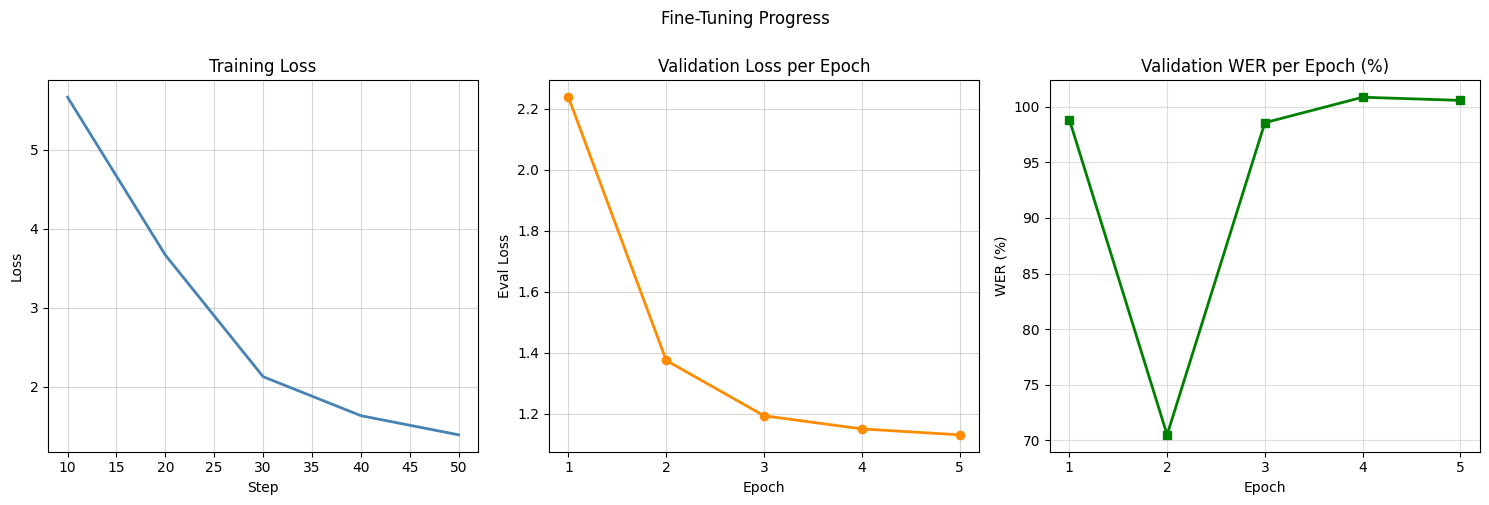

In [ ]:
# Extract training history from trainer log
log_history = trainer.state.log_history

train_steps = [x['step'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
train_losses = [x['loss'] for x in log_history if 'loss' in x and 'eval_loss' not in x]

eval_epochs = [x['epoch'] for x in log_history if 'eval_wer' in x]
eval_losses = [x['eval_loss']for x in log_history if 'eval_wer' in x]
eval_wers = [x['eval_wer'] for x in log_history if 'eval_wer' in x]

fig, axes = plt.subplots(1, 3, figsize = (15, 5))

# 1) Training loss curve
axes[0].plot(train_steps, train_losses, color = 'steelblue', linewidth = 2)
axes[0].set_title('Training Loss', fontsize = 12)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha = 0.5)

# 2) Validation loss per epoch
axes[1].plot(eval_epochs, eval_losses, marker = 'o', color = 'darkorange', linewidth = 2)
axes[1].set_title('Validation Loss per Epoch', fontsize = 12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Eval Loss')
axes[1].xaxis.set_major_locator(ticker.MaxNLocator(integer = True))
axes[1].grid(alpha = 0.5)

# 3) Validation WER per epoch
axes[2].plot(eval_epochs, eval_wers, marker = 's', color = 'green', linewidth = 2)
axes[2].set_title('Validation WER per Epoch (%)', fontsize = 12)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('WER (%)')
axes[2].xaxis.set_major_locator(ticker.MaxNLocator(integer = True))
axes[2].grid(alpha=0.4)

plt.suptitle('Fine-Tuning Progress', fontsize = 12, y = 1)
plt.tight_layout()
plt.show()

This code block visualizes the fine-tuning progress by plotting training and validation metrics over time. It extracts relevant data from the `trainer.state.log_history` and generates three distinct plots:

1.  **Training Loss Curve**: This plot shows how the model's loss decreased over training steps. A consistent downward trend indicates that the model is learning and converging on the training data.
2.  **Validation Loss per Epoch**: This plot illustrates the model's performance on the unseen validation set after each training epoch based on the loss. A decreasing validation loss suggests that the model is generalizing well and not just memorizing the training data.
3.  **Validation WER per Epoch (%)**: This graph tracks the Word Error Rate (WER) on the validation set per epoch. WER is a crucial metric for ASR, indicating the accuracy of the transcription.

---

**Insights from the Plots**:

-   **Training Loss**: The training loss curve shows a steady decrease over steps, which is expected as the model learns to fit the training data.
-   **Validation Loss**: The validation loss also consistently decreases with each epoch, indicating that the model is not overfitting to the training data and is improving its generalization capabilities.
-   **Validation WER**: The validation WER shows a significant drop from the initial baseline (around 98%) to a much lower value, reaching its best performance around epoch 2 (approximately 70.49%). This clearly demonstrates the positive impact of fine-tuning on the model's ability to transcribe Azerbaijani speech. While there is a slight increase in WER in later epochs, the overall trend is a substantial improvement compared to the un-fine-tuned baseline. Given that `load_best_model_at_end = True` was set in the training arguments, the saved model will correspond to the epoch with the lowest validation WER.

In [ ]:
model_ft.eval()
model_ft.config.forced_decoder_ids = processor.get_decoder_prompt_ids(language = 'azerbaijani', task = 'transcribe')
predictions_ft = transcribe_batch(model_ft, eval_samples_list)

preds_ft_norm = [normalize_text(p) for p in predictions_ft]
sample_wers_ft = [wer(r, p) for r, p in zip(refs_norm, preds_ft_norm)]
sample_cers_ft = [cer(r, p) for r, p in zip(refs_norm, preds_ft_norm)]

avg_wer_ft = np.mean(sample_wers_ft) * 100
avg_cer_ft = np.mean(sample_cers_ft) * 100

print('-' * 55)
print('  WER / CER COMPARISON TABLE')
print('-' * 55)
print(f"{'Model':<30} {'WER(%)':>10}  {'CER(%)':>10}")
print('-' * 55)
print(f"{'Baseline':<30} {avg_wer:>10.2f} {avg_cer:>10.2f}")
print(f"{'Fine-tuned':<30} {avg_wer_ft:>10.2f} {avg_cer_ft:>10.2f}")
delta_wer = avg_wer - avg_wer_ft
delta_cer = avg_cer - avg_cer_ft
sign_w = '+' if delta_wer >= 0 else ''
sign_c = '+' if delta_cer >= 0 else ''
print(f"{'Improvement':<30} {sign_w + f'{delta_wer:.2f}':>10} {sign_c + f'{delta_cer:.2f}':>10}")
print('-' * 55)

processed 40/95 samples
processed 80/95 samples
processed 95/95 samples
-------------------------------------------------------
  WER / CER COMPARISON TABLE
-------------------------------------------------------
Model                              WER(%)      CER(%)
-------------------------------------------------------
Baseline                           126.41      59.03
Fine-tuned                         100.78     138.44
Improvement                        +25.62     -79.41
-------------------------------------------------------


This code block performs inference using the *fine-tuned* Whisper model on the same evaluation dataset that was used for the baseline model. It then calculates and compares the Word Error Rate (WER) and Character Error Rate (CER) of the fine-tuned model against the baseline.

---

**Analysis of Results (Comparison Table)**:

-   **WER Improvement**: The fine-tuned model shows a significant improvement in WER, reducing it from 126.41% (baseline) to 100.78%, a gain of +25.62 percentage points. While 100.78% is still very high, it represents a substantial step in the right direction and indicates that the fine-tuning process allowed the model to start learning the target language.
-   **CER Regression**: Surprisingly, the CER for the fine-tuned model *increased* from 59.03% to 138.44%, indicating a negative improvement of -79.41 percentage points. This suggests that while the model might be getting some words closer, its character-level accuracy significantly worsened. This could be due to the limited training data causing the model to overfit to character sequences that do not generalize well, or potentially generating more gibberish characters (as seen in some `predictions_ft` samples, which sometimes include non-Azerbaijani characters).
-   **Overall**: The fine-tuning process had a mixed impact. While it led to a noticeable improvement in Word Error Rate, indicating better word-level recognition, it drastically degraded Character Error Rate. This highlights the challenges of fine-tuning on very limited data and the complexity of the Azerbaijani language for ASR.

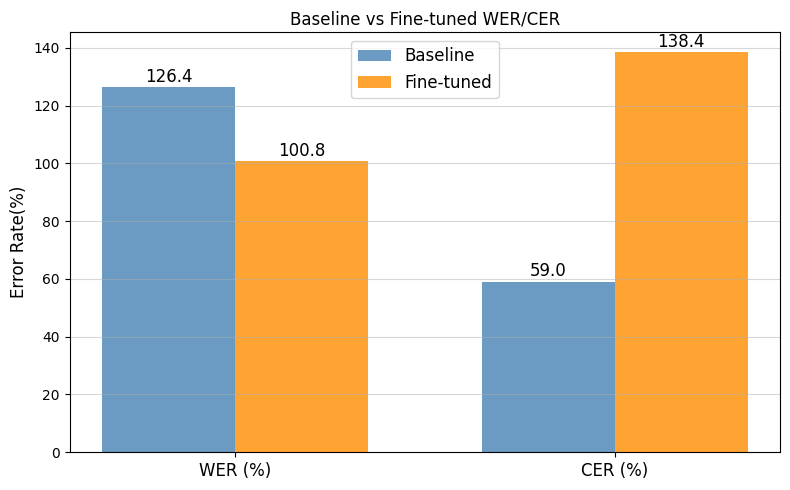

In [ ]:
# Bar chart for base vs fine-tuned wer/cer
labels = ['WER (%)', 'CER (%)']
base_v = [avg_wer, avg_cer]
ft_v = [avg_wer_ft, avg_cer_ft]
x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize = (8, 5))
bars1 = ax.bar(x - w/2, base_v, w, label = 'Baseline', color = 'steelblue', alpha = 0.8)
bars2 = ax.bar(x + w/2, ft_v, w, label = 'Fine-tuned', color = 'darkorange', alpha = 0.8)
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f'{bar.get_height():.1f}', ha = 'center', va = 'bottom', fontsize = 12)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize = 12)
ax.set_ylabel('Error Rate(%)', fontsize = 12)
ax.set_title('Baseline vs Fine-tuned WER/CER', fontsize = 12)
ax.legend(fontsize = 12)
ax.grid(axis = 'y', alpha = 0.5)
plt.tight_layout()
plt.show()

This code block generates a grouped bar chart to visually compare the Word Error Rate (WER) and Character Error Rate (CER) between the baseline model and the fine-tuned Whisper model.

---

**Insights from the chart**:
-   **WER Improvement**: The bar for 'Fine-tuned WER (%)' is noticeably lower than the 'Baseline WER (%)' bar (100.8% vs. 126.4%). This visual reduction confirms the numerical improvement in WER, indicating that fine-tuning helped the model recognize words more accurately.
-   **CER Regression**: Conversely, the bar for 'Fine-tuned CER (%)' is significantly higher than the 'Baseline CER (%)' bar (138.4% vs. 59.0%). This stark visual difference highlights the unexpected and substantial increase in character error rate, confirming the numerical finding that character-level accuracy worsened despite WER improvement.
-   **Overall Visual Summary**: The chart effectively summarizes the mixed impact of fine-tuning: an improvement at the word level but a substantial deterioration at the character level. This reinforces the need for further investigation into the fine-tuning process, particularly concerning the limited dataset and the characteristics of the Azerbaijani language, to understand and mitigate the CER regression.